<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK09_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.3 전이 학습

- 합성곱 신경망 기반의 딥러닝 모델을 제대로 훈련시키기 위해 많은 양의 데이터가 필요
- 하지만 큰 데이터셋을 얻기는 쉽지 않음
- 이 문제점을 해결한 것 = 전이 학습
  - 전이학습이란, 이미지넷처럼 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 해결하고자 하는 과제에 맞게 보정하여 사용하는 것을 의미
  - 아주 큰 데이터셋을 사용하여 훈련된 모델 = 사전 훈련된 모델 = 네트워크

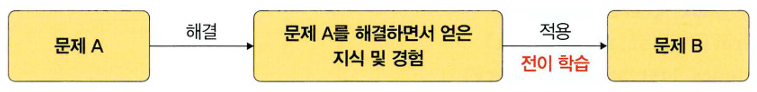

## 5.3.1 특성 추출 기법

- 특성추출은 이미지넷 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만듦
  - 즉, 학습할 때 마지막 완전연결층만 학습하고 나머지 계층들은 학습되지 않도록 함
- 특성추출
  - 합성곱층 : 합성곱과 풀링층으로 구성
  - 데이터 분류기(완전연결층) : 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분

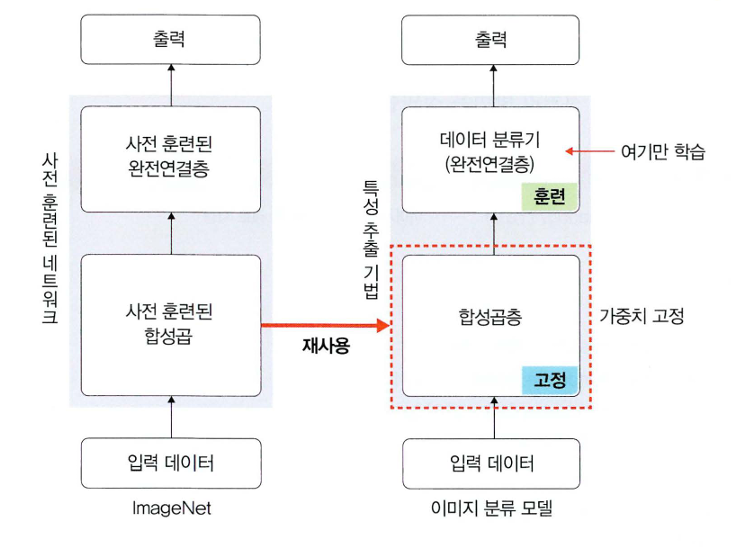

< 요약 >

사전 학습된 합성곱층의 가중치는 이미 고정해두고, 새로운 입력 이미지가 들어오면 그 가중치를 이용해서 이미지의 특징을 추출함

그리고 그 추출된 특징을 입력값으로 받아서 완전연결층만 새롭게 학습함

그래서 나중에 새로운 이미지가 들어왔을 때, 합성곱층은 특징만 뽑아주고, 완전연결층이 그 특징을 보고 새 과제에 맞게 분류

In [ ]:
# 5-12 라이브러리 호출
import os
import time
import copy
import glob
import cv2  # 앞에서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision  # 컴퓨터 비전(computer vision) 용도의 패키지
import torchvision.transforms as transforms  # 데이터 전처리를 위해 사용되는 패키지
import torchvision. models as models  # 다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch .utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 32.84 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [ ]:
data_path = './080289/chap05/data/catanddog/train/'

transform = transforms.Compose(
    [
        transforms.Resize([256,256]), # 256x256 크기로 이미지 데이터 조정.
        transforms.RandomResizedCrop(224), # 이미지를 랜덤한 크기 및 비율로 자름.
        transforms.RandomHorizontalFlip(), # 이미지를 랜덤하게 수평으로 뒤집음.
        transforms.ToTensor() # 이미지를 텐서로 변환.
    ]
) # 이미지 데이터를 변환하여 모델의 입력으로 사용할 수 있게 변환.
train_dataset = torchvision.datasets.ImageFolder(data_path, transform=transform)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8, # 데이터를 불러 올 때 하위 프로세스 몇 개 사용할지 설정.
    shuffle=True
)
print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


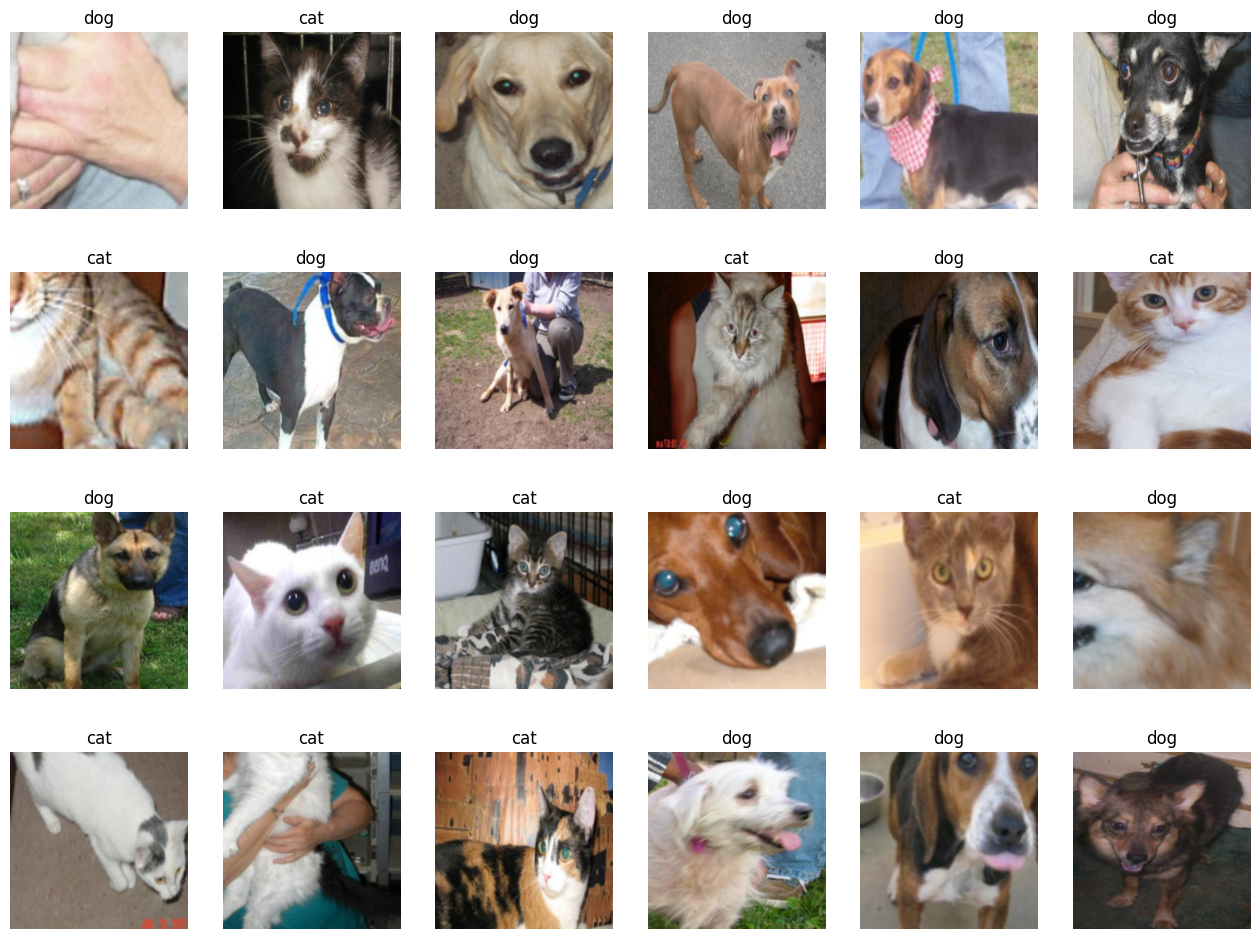

In [ ]:
import numpy as np

samples, labels = next(iter(train_loader))
# iter : 전달된 데이터의 반복자를 꺼내 반환
# next : 그 반복자가 다음에 출력해야 할 요소 반환

classes = {0: 'cat', 1: 'dog'}

fig = plt.figure(figsize=(16, 24))

for i in range(24):
    a = fig.add_subplot(4, 6, i + 1)
    a.set_title(classes[labels[i].item()])
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0)))

plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
plt.show()

In [ ]:
# 5-15 사전 훈련된 모델 내려받기
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 62.0MB/s]


- pretrained=True
  - 사전 학습된 가중치를 사용하겠다는 의미

In [ ]:
# 5-16 사전 훈련된 모델의 파라미터 학습 유무 지정
def set_parameter_requires_grad(model , feature_extracting=True ):
  if feature_extracting:
    for param in model .parameters():
      param.requires_grad = False

set_parameter_requires_grad(resnet18)

- param.requires_grad = False
  - 역전파 중 파라미터들에 대한 변화 계산 필요 없음 > 모델 일부 고정, 나머지 학습

In [ ]:
# 5-17 완전연결층 추가
resnet18.fc = nn.Linear(512, 2)  # 2는 클래스가 두 개라는 의미

In [ ]:
# 5-18 모델의 파라미터 값 확인
for name, param in resnet18.named_parameters( ):
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[ 0.0178, -0.0009, -0.0440,  ...,  0.0077,  0.0140,  0.0363],
        [ 0.0422,  0.0440,  0.0117,  ..., -0.0330,  0.0232,  0.0130]])
fc.bias tensor([-0.0128,  0.0065])


- 결과와 같이, 파라미터는 weight, bias 사용됨
- model.named_parameters()는 모델에 접근하여 파라미터 값들을 가져올 때 사용

In [ ]:
# 5-19 모델 객체 생성 및 손실 함수 정의
model = models.resnet18( pretrained=True )  # 모델의 객체 생성

for param in model. parameters ():  # 모델의 합성곱층 가중치 고정
  param. requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model. fc. parameters ():  # 완전연결층은 학습
  param .requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss ()   # 손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# 5-20 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time()
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders.dataset)
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('./080289/chap05/data/catanddog/', '{0:0=2d}.pth'.format(epoch)))
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))
    return acc_history, loss_history

In [ ]:
# 5-21 파라미터 학습 결과를 옵티마이저에 저장
params_to_update = []
for name , param in resnet18.named_parameters():
  if param .requires_grad == True:
    params_to_update.append(param)  # 파라미터 학습 결과를 저장
    print('\t', name)

optimizer = optim.Adam(params_to_update)  # 학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


In [ ]:
# 5-22 모델 학습
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
criterion = nn. CrossEntropyLoss ()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.6154 Acc: 0.6623

Epoch 1/12
----------
Loss: 0.4160 Acc: 0.8078

Epoch 2/12
----------
Loss: 0.3055 Acc: 0.8753

Epoch 3/12
----------
Loss: 0.3106 Acc: 0.8675

Epoch 4/12
----------
Loss: 0.3318 Acc: 0.8234

Epoch 5/12
----------
Loss: 0.2219 Acc: 0.9273

Epoch 6/12
----------
Loss: 0.2438 Acc: 0.9013

Epoch 7/12
----------
Loss: 0.2202 Acc: 0.9091

Epoch 8/12
----------
Loss: 0.2000 Acc: 0.9325

Epoch 9/12
----------
Loss: 0.2039 Acc: 0.9143

Epoch 10/12
----------
Loss: 0.2015 Acc: 0.9247

Epoch 11/12
----------
Loss: 0.1871 Acc: 0.9351

Epoch 12/12
----------
Loss: 0.2346 Acc: 0.9143

Training complete in 9m 11s
Best Acc: 0.935065


In [ ]:
# 5-23 테스트 데이터 호출 및 전처리
test_path = './080289/chap05/data/catanddog/test/'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)
print(len(test_dataset))

98


In [ ]:
# 5-24 테스트 데이터 평가 함수 생성
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('./080289/chap05/data/catanddog/' + '*.pth')
  saved_models.sort()
  print('saved_model', saved_models)

  for model_path in saved_models :
    print( 'Loading model' , model_path)

    model .load_state_dict(torch.load(model_path))
    model .eval()
    model .to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:  # 테스트 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad():  # autograd를 사용하지 않겠다는 의미
        outputs = model (inputs)  # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs, 1)  # max : 텐서 배열의 최댓값이 들어 있는 index 반환
      preds [preds >= 0.5] = 1  # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
      preds [preds < 0.5] = 0  # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds .eq(labels.cpu()).int().sum()

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)  # 테스트 데이터의 정확도 계산
    print( 'Acc: {:.4f} '.format (epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
      acc_history .append(epoch_acc .item())
      print()

    time_elapsed = time.time() - since
    print ('Validation complete in {: .0f}m {: .0f}s'.format (time_elapsed // 60 , time_elapsed % 60 ))
    print( "Best Acc: {:4f}".format (best_acc))

    return acc_history # 계산된 정확도 반환

In [ ]:
# 5-25 테스트 데이터를 평가 함수에 적용
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['./080289/chap05/data/catanddog/00.pth', './080289/chap05/data/catanddog/01.pth', './080289/chap05/data/catanddog/02.pth', './080289/chap05/data/catanddog/03.pth', './080289/chap05/data/catanddog/04.pth', './080289/chap05/data/catanddog/05.pth', './080289/chap05/data/catanddog/06.pth', './080289/chap05/data/catanddog/07.pth', './080289/chap05/data/catanddog/08.pth', './080289/chap05/data/catanddog/09.pth', './080289/chap05/data/catanddog/10.pth', './080289/chap05/data/catanddog/11.pth', './080289/chap05/data/catanddog/12.pth']
Loading model ./080289/chap05/data/catanddog/00.pth
Acc: 0.7653 

Validation complete in  0m  10s
Best Acc: 0.765306


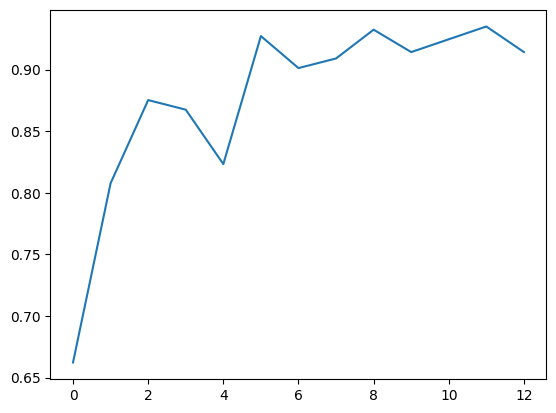

In [ ]:
# 5-26 훈련과 테스트 데이터의 정확도를 그래프로 확인
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

- 에포크가 진행될수록 정확도가 높아지며 100%에 가까워지고 있음

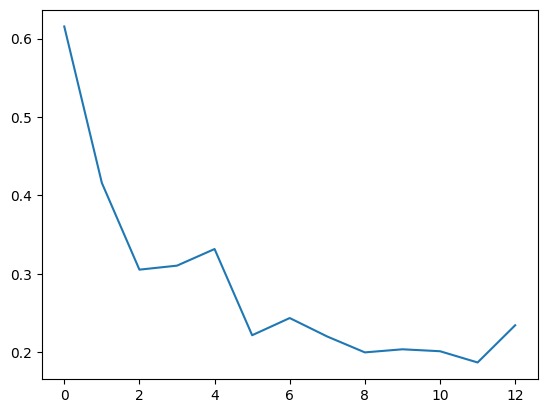

In [ ]:
# 5-27 훈련 데이터의 오차에 대한 그래프 확인
plt.plot(train_loss_hist)
plt.show()

In [ ]:
# 5-28 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy()  # 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향 X
  image = image.transpose(1, 2, 0)
  image = image * (np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0, 1)  # data를 0과 1 사이의 값으로 제한
  return image

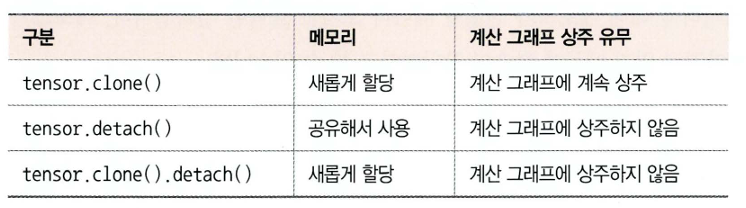

< clip 예시 >

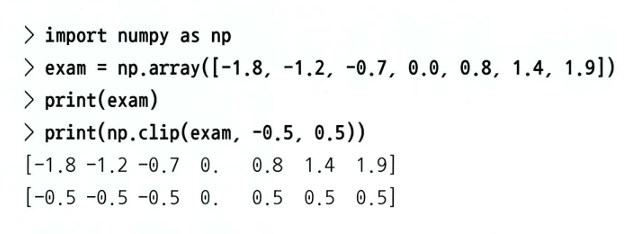

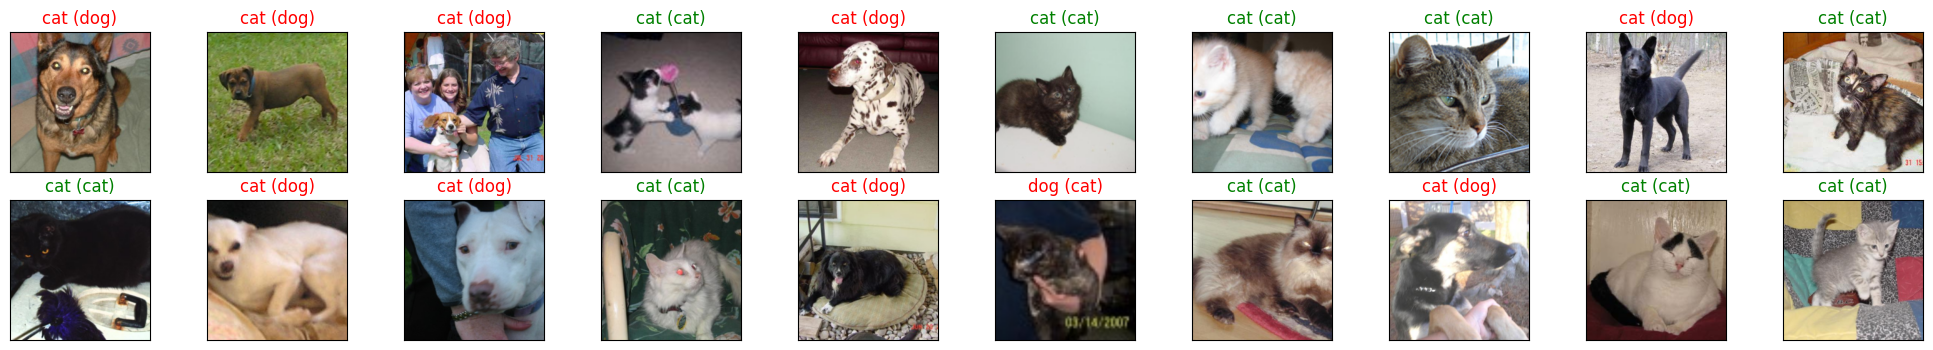

<Figure size 640x480 with 0 Axes>

In [ ]:
# 5-29 개와 고양이 예측 결과 출력
classes = {0: 'cat', 1: 'dog' }  # 개와 고앙이 두 개에 대한 레이블
dataiter = iter(test_loader)  # 테스트 데이터셋 가져오기
images, labels = next(dataiter)  # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져오기
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig .add_subplot(2, 10, idx+1 , xticks=[] , yticks=[])
  plt. imshow (im_convert (images [idx] ))  # 이미지 출력을 위해 코드 5-28에서 정의한 im_convert 함수를 적용
  a.set_title(classes[labels[i].item()])
  ax.set_title("{} ({})" .format(str(classes[preds [idx].item()]), str(classes[labels[idx]. item()])),
               color=( "green" if preds [idx]==labels[idx] else "red" ))
plt. show()
plt. subplots_adjust(bottom=0.2, top=0.6, hspace=0)

## 5.3.2 미세 조정 기법

- 사전 훈련된 모델의 가중치를 일부 또는 전체 업데이트하여 새로운 데이터에 맞게 재학습하는 방법
- 특성 추출 기법에서 더 나아가 합성곱층까지 학습 범위를 확장하는 방식
- 기존 모델이 추출한 특징이 새로운 데이터에 부적합할 경우 성능 개선을 위해 사용
- 전체 또는 일부 계층의 가중치를 조정하여 특징을 다시 학습

**1. 데이터셋 큼 + 유사도 낮음**
- 모델 전체 재학습 수행
- 새로운 특징 학습 필요
- 데이터 충분 → 과적합 위험 낮음

**2. 데이터셋 큼 + 유사도 높음**
- 합성곱층 뒷부분 + 분류기 학습
- 기존 특징 활용 가능함
- 일부 계층만 재학습으로 효율성 확보함

**3. 데이터셋 작음 + 유사도 낮음**
- 합성곱층 일부 + 분류기 선택적 학습
- 과적합 위험 존재함
- 학습 범위 조절 필요

**4. 데이터셋 작음 + 유사도 높음**
- 완전연결층(분류기)만 학습
- 대부분 계층 고정함
- 과적합 방지를 위한 최소 학습 수행